### Applying Principal Component Analysis on XBP1 and GATA3 expression levels.

Loading the data from the data files.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

class_labels = pd.read_csv("class.tsv", header=None, names=["Class"])["Class"]

columns_df = pd.read_csv("columns.tsv", sep="\t", comment="#")

gene_ids = columns_df.set_index("GeneSymbol").loc[["XBP1", "GATA3"]]["ID"].astype(str).tolist()

with open("filtered.tsv", "r") as f:
    expression_df = pd.read_csv(f, sep="\t")

expression_df.columns = expression_df.columns.str.strip()

Plotting the scatter plot for expression levels.

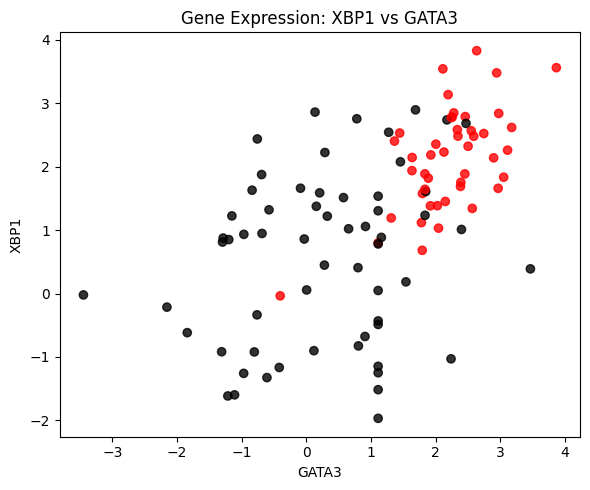

In [4]:
# Extract expression levels for XBP1 and GATA3
expressions = expression_df[gene_ids].copy()
expressions.columns = ["XBP1", "GATA3"]

# Scatter plot
plt.figure(figsize=(6, 5))
colors = class_labels.map({1: "red", 0: "black"})
plt.scatter(expressions["GATA3"], expressions["XBP1"], c=colors, alpha=0.8)
plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Gene Expression: XBP1 vs GATA3")
plt.tight_layout()
plt.show()

Running PCA on the expression level matrix.

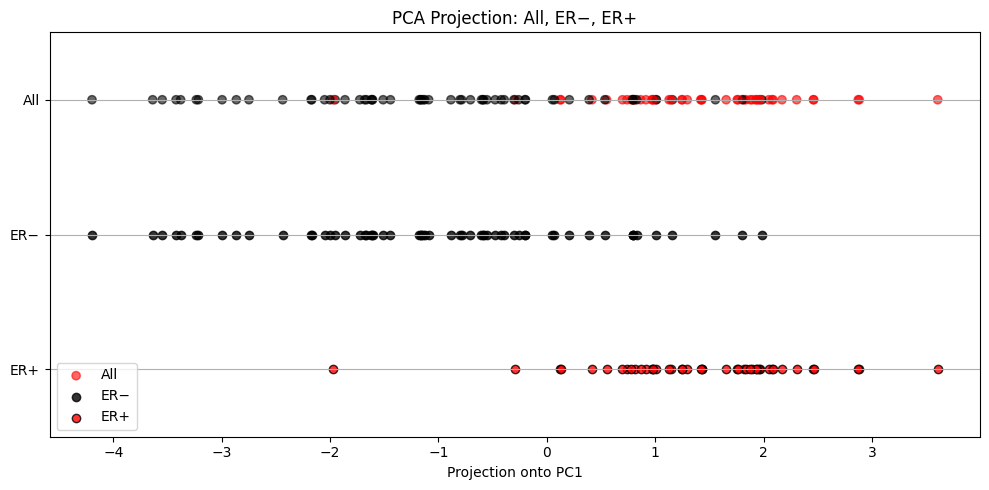

In [3]:
# Compute PCA
pca = PCA(n_components=1)
pc1 = pca.fit_transform(expressions)

# Define colors
colors = class_labels.map({1: "red", 0: "black"})

# Y-offsets: All on top, then ER−, then ER+
er_all = [2] * len(pc1)
er_neg = [1 if c == 0 else np.nan for c in class_labels]
er_pos = [0 if c == 1 else np.nan for c in class_labels]

plt.figure(figsize=(10, 5))

# Plot All samples on top (black for visibility)
plt.scatter(pc1, er_all, color=colors, alpha=0.6, label='All')

# Overlay ER− and ER+ with edge color
plt.scatter(pc1, er_neg, c='black', label='ER−', alpha=0.8, edgecolor='k')
plt.scatter(pc1, er_pos, c='red', label='ER+', alpha=0.8, edgecolor='k')

# Format y-axis
plt.yticks([0, 1, 2], ["ER+", "ER−", "All"])
plt.ylim(-0.5, 2.5)
plt.xlabel("Projection onto PC1")
plt.title("PCA Projection: All, ER−, ER+")
plt.grid(True, axis='y')
plt.legend()
plt.tight_layout()
plt.show()